# Analiza uticaja tehničkih i kategorijskih karakteristika laptopa na cenu

- **Autor:** Sara Mladenovic
- **Predmet:** Numerički Algoritmi i Numericki Softver

<a id='uvod'></a>
## 1. Inicijalizacija i import biblioteka


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


from data_preprocessing import full_preprocessing_pipeline
from eda_visualization import (
    set_plot_style, plot_price_distribution, plot_categorical_distributions,
    plot_numeric_distributions, plot_price_by_categorical, plot_price_by_numeric,
    detect_outliers_iqr, plot_correlation_matrix, calculate_vif, plot_memory_types_distribution, plot_binary_distribution, 
    analyze_multidrive_effect ,plot_key_interactions
)
from regression_models import RegressionModels
set_plot_style()


<a id='preprocessing'></a>
## 2. Ucitavanje i preprocessing podataka

- Ucitavanje i ciscenje podataka
- Feature engineering (RAM, tezina, rezolucija, memorija, CPU i GPU)
- One-hot encoding kategorickih promenljivih
- Podela podataka na train/validation/test skup
- Standardizacija numerickih atributa

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names, df_processed = \
    full_preprocessing_pipeline('../data/laptop_price.csv')

Ucitano 1303 redova i 13 kolona
Uklonjene kolone: ['laptop_ID', 'Product']
Nema nedostajućih vrednosti
Ekstraktovane numericke vrednosti: Ram_GB, Weight_kg
Obradjena rezolucija ekrana: Screen_Width, Screen_Height, Total_Pixels, IPS_Panel, Touchscreen, Retina
Obradjena memorija: Has_SSD, Has_HDD, Has_Flash, Has_Hybrid, Has_MultiDrive, Total_Storage_GB
Obradjeen CPU: CPU_Brand, CPU_Type, CPU_Speed_GHz
Obradjen GPU: GPU_Brand

Provera NaN vrednosti nakon feature engineeringa:
Nema NaN vrednosti.
Primenjujem one-hot encoding na: ['Company', 'TypeName', 'OpSys', 'CPU_Brand', 'CPU_Type', 'GPU_Brand']
Ukupno kolona nakon encodinga: 71

 Podela podataka:
  Training:   781 instanci (59.9%)
  Validation: 261 instanci (20.0%)
  Test:       261 instanci (20.0%)

 Standardizovano 16 numerickih features


<a id='eda'></a>
## 3. Eksploratorna analiza podataka (EDA)

- Distribucije svih promenljivih (numerickih i kategorickih)
- Odnosi izmedju promenljivih
- Identifikaciju outliera
- Multikolinearnost izmedju features

### 3.1 Distribucija ciljne promenljive (cena)

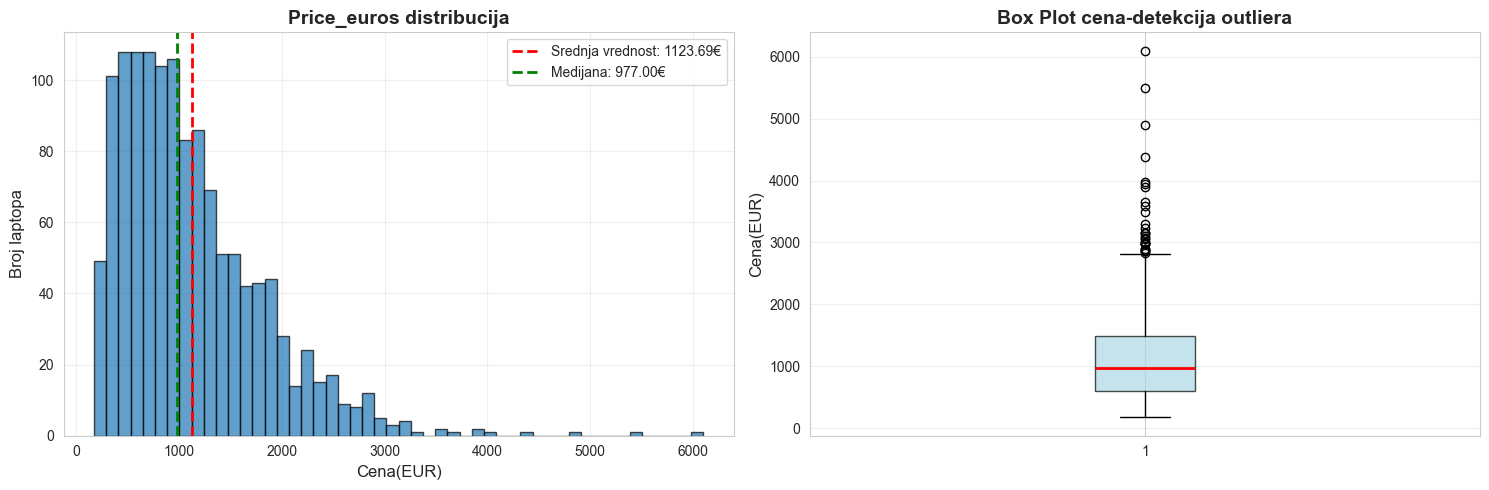

Statiskitka: 
Srednja vrednost: 1123.69 €
Medijana:         977.00 €
Std. devijacija:  699.01 €
Minimum:          174.00 €
Maximum:          6099.00 €
25% percentil:    599.00 €
75% percentil:    1487.88 €


In [3]:
plot_price_distribution(df_processed)

Analiza asimetrije (skewness)

In [4]:
price_skew = stats.skew(df_processed['Price_euros'])
print(f"Skewness: {price_skew:.3f}")

Skewness: 1.519


- Distribucija cena laptopova pokazuje pozitivnu asimetriju (skewness = 1.519), sto znaci da je raspodela desno nageta.
- Mean (1123.69 EUR) je veci od medijane (977.00 EUR), sto ukazuje na prisustvo skupljih modela koji podizu prosek.
- Vecina laptopova se nalazi u nizem i srednjem cenovnom rangu.
- 25% laptopova kosta manje od 599 EUR.
- 75% laptopova kosta manje od 1487.88 EUR.
- To znaci da se 50% laptopova nalazi u opsegu od 599 do 1487.88 EUR, sto predstavlja tipican cenovni raspon.
- Postoji manji broj skupih laptopova (outlieri) koji formiraju desni rep distribucije.

### 3.2 Distribucije kategoričkih promenljivih

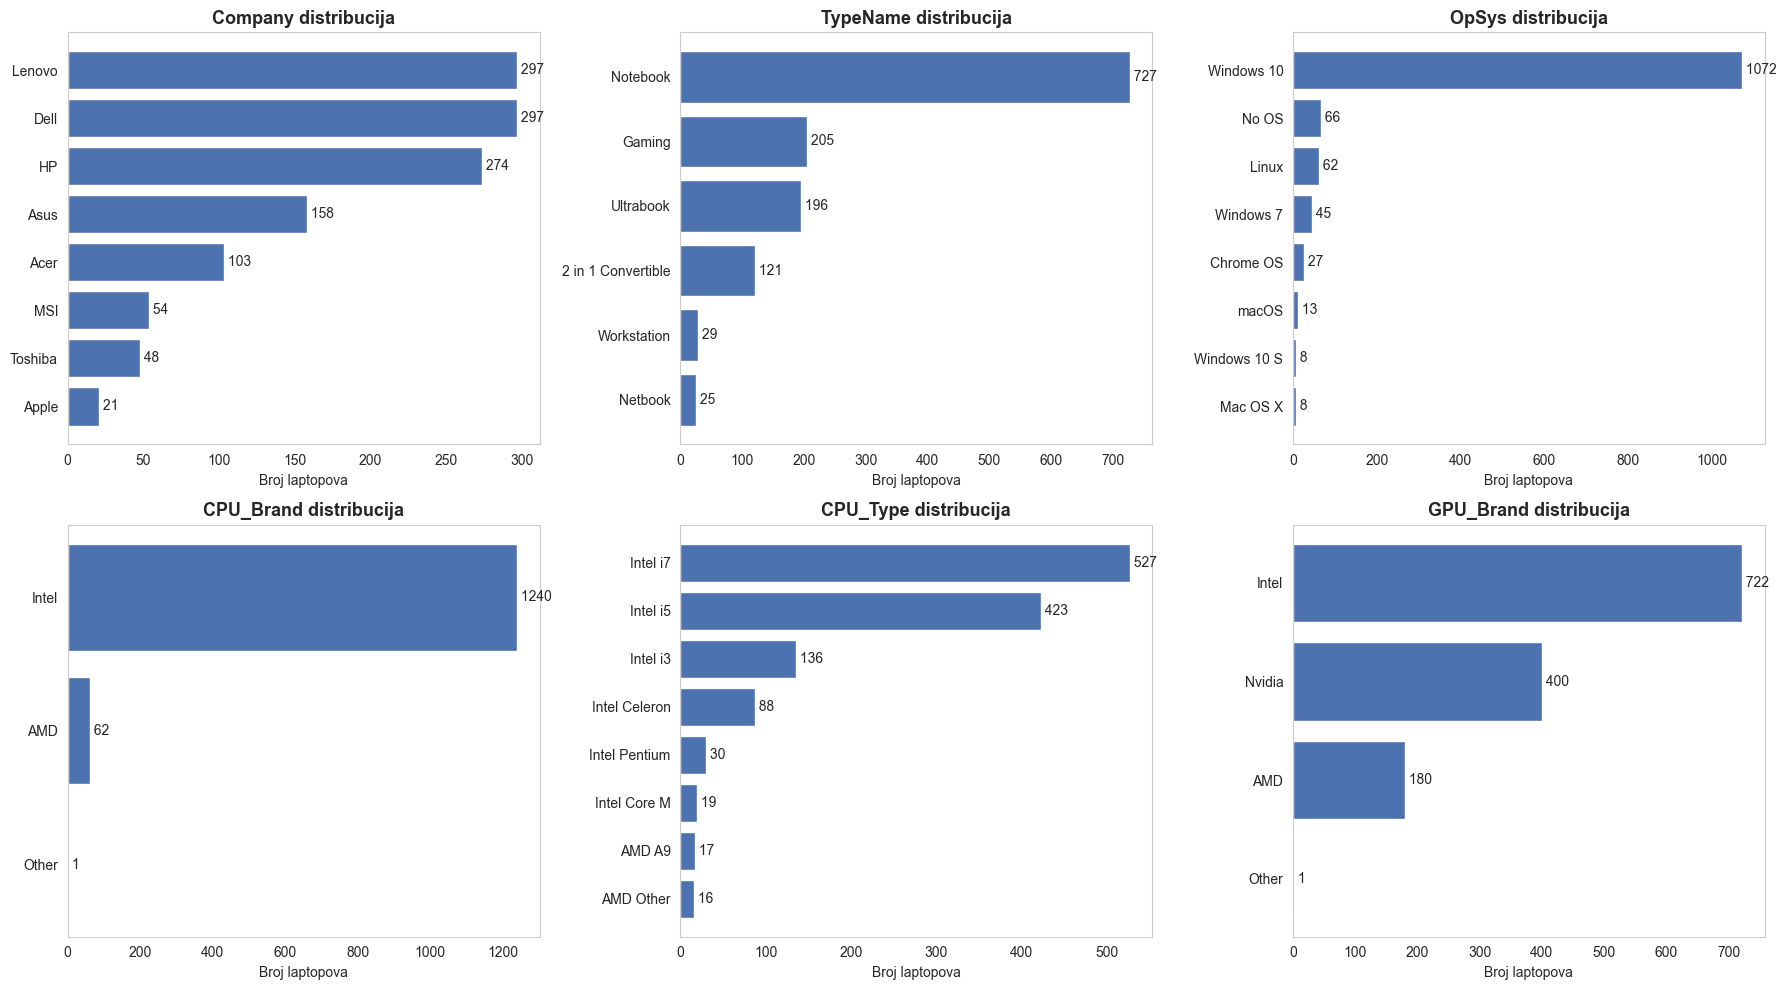

In [5]:
plot_categorical_distributions(df_processed)

- Zakljucak distribucije kategorijskih promenljivih
- Trziste je dominantno zastupljeno brendovima Lenovo, Dell i HP.
- Najzastupljeniji tip laptopa je Notebook, zatim Gaming i Ultrabook modeli.
- Operativni sistem Windows 10 apsolutno dominira u odnosu na ostale sisteme.
- Intel procesori su daleko najzastupljeniji u odnosu na AMD.
- Najcesci tip procesora su Intel i7 i i5 modeli.
- U pogledu grafickih kartica, Intel i Nvidia imaju znacajnu dominaciju, dok je AMD slabije zastupljen.

### 3.3 Distribucije numerickih promenljivih

**Distribucija numericke promenljive Ram**

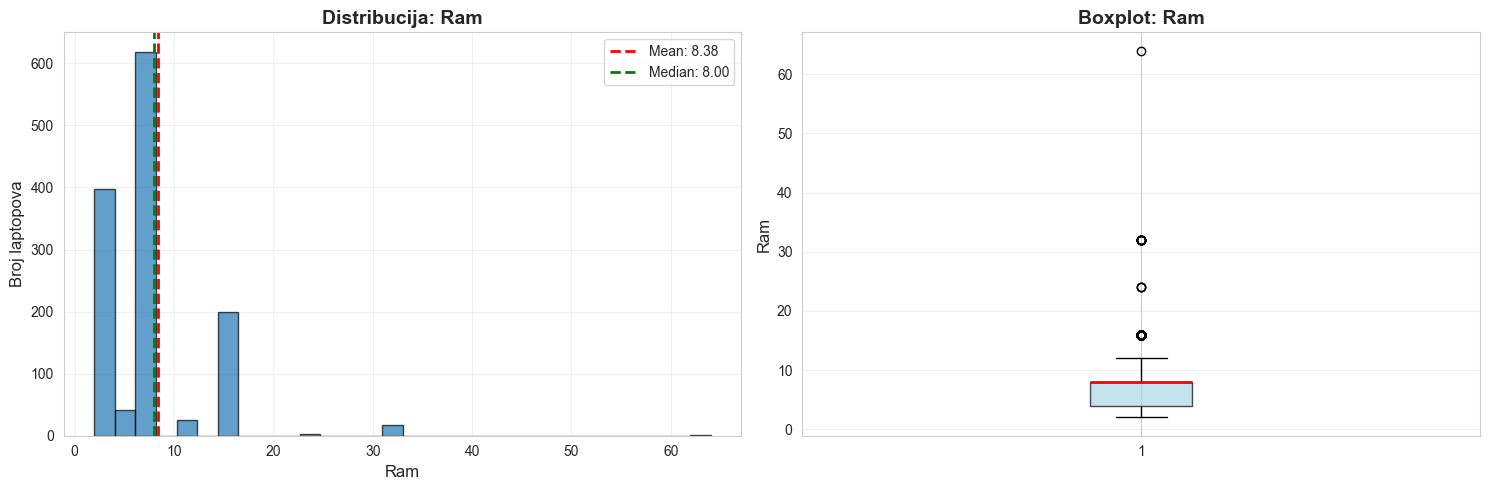

Statistika:
Srednja vrednost: 8.38
Medijana:         8.00
Std. devijacija:  5.08
Minimum:          2.00
Maximum:          64.00
25% percentil:    4.00
75% percentil:    8.00


In [6]:
plot_numeric_distributions(df_processed,"Ram")

- Analiza pokazuje da vecina laptopova u datasetu poseduje izmedju 4GB i 8GB RAM memorije, pri cemu je medijana 8GB.
- Srednja vrednost iznosi 8.38GB, sto ukazuje na blagu desnu asimetriju distribucije usled prisustva modela sa vecim kapacitetima memorije (16GB, 32GB i 64GB).
- Boxplot potvrdjuje postojanje outliera u gornjem delu distribucije, sto je ocekivano jer premium modeli imaju znatno vecu RAM memoriju.
- Moze se zakljuciti da je 8GB najzastupljeniji kapacitet RAM-a u posmatranom skupu podataka

**Distribucija numericke promenljive Weight**

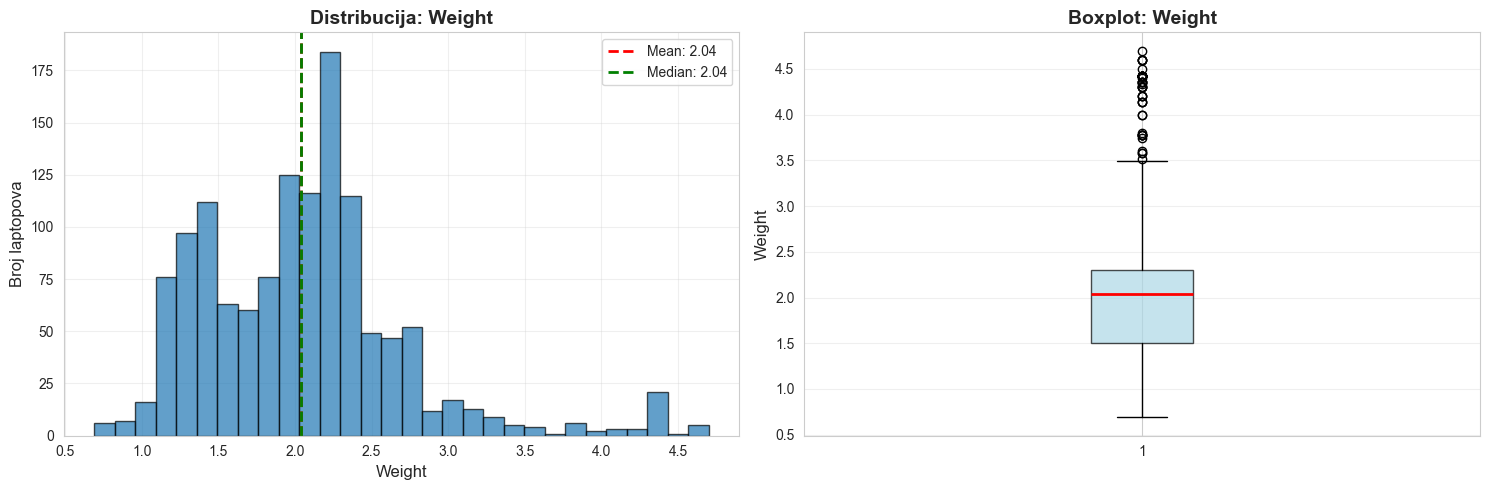

Statistika:
Srednja vrednost: 2.04
Medijana:         2.04
Std. devijacija:  0.67
Minimum:          0.69
Maximum:          4.70
25% percentil:    1.50
75% percentil:    2.30


In [7]:
plot_numeric_distributions(df_processed,"Weight")

- Prosecna tezina laptopova u datasetu iznosi oko 2 kg, pri cemu su srednja vrednost i medijana jednake (2.04 kg), sto ukazuje na gotovo simetricnu distribuciju.
- Polovina laptopova ima tezinu izmedju 1.50 kg i 2.30 kg, sto pokazuje da je vecina modela srednje tezine.
- Postoje outlieri u gornjem delu distribucije, koji predstavljaju teze gaming ili workstation modele.
- Tipican laptop u datasetu tezak oko 2 kg, sto odgovara standardnim trzisnim karakteristikama.

**Distribucija numericke promenljive Inches**

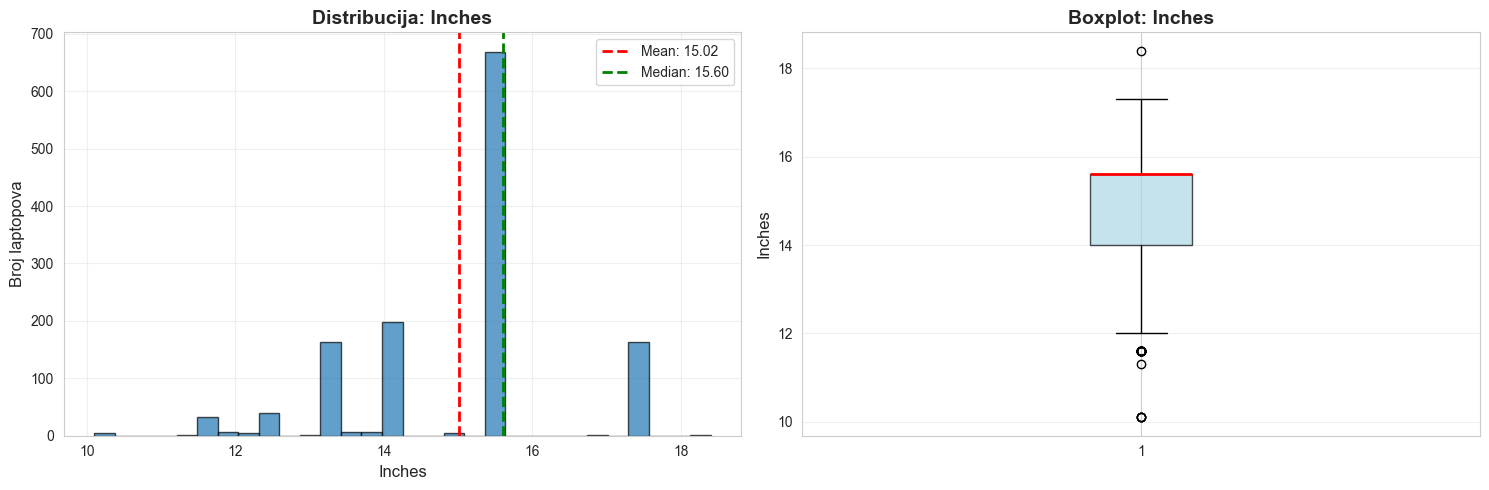

Statistika:
Srednja vrednost: 15.02
Medijana:         15.60
Std. devijacija:  1.43
Minimum:          10.10
Maximum:          18.40
25% percentil:    14.00
75% percentil:    15.60


In [8]:
plot_numeric_distributions(df_processed,"Inches")

- Prosecna dijagonala ekrana iznosi oko 15 inca, pri cemu je medijana 15.6 inca, sto ukazuje na blagu levu asimetriju distribucije.
- Polovina laptopova ima velicinu ekrana izmedju 14 i 15.6 inca, sto pokazuje da je ovaj opseg najzastupljeniji u datasetu.
- Postoje outlieri kod manjih (10–11 inca) i vecih modela (17–18 inca), koji predstavljaju ultrabook i gaming uredjaje.
-  15.6 inca dominantan standard u posmatranom skupu podataka.

**Distribucija numericke promenljive CPU_Speed_GHz**

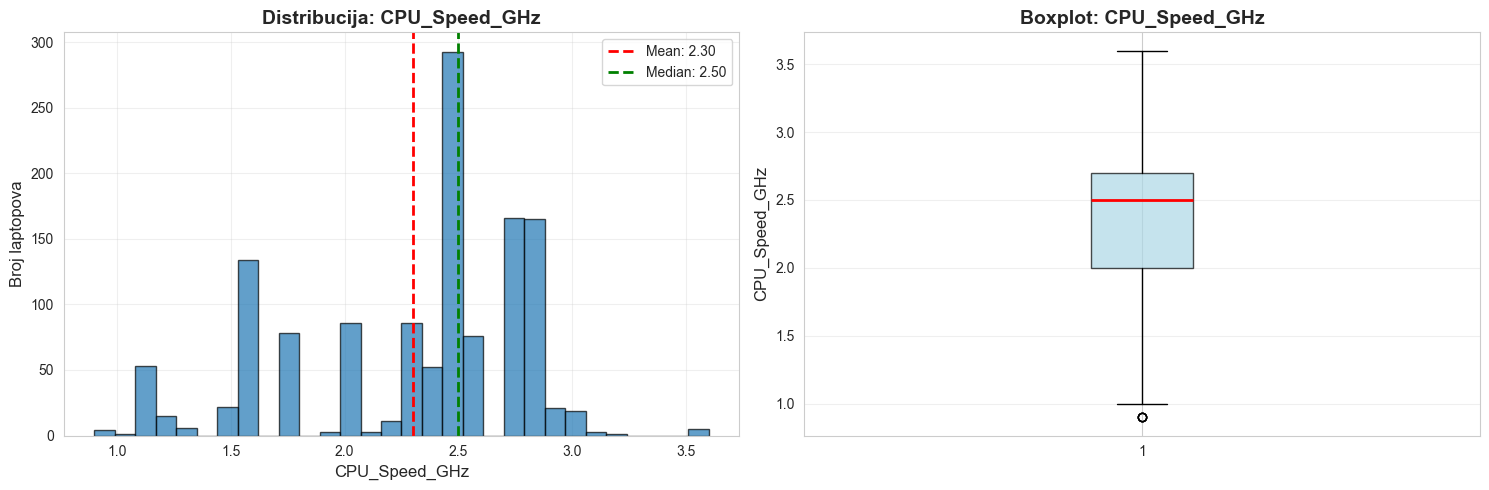

Statistika:
Srednja vrednost: 2.30
Medijana:         2.50
Std. devijacija:  0.51
Minimum:          0.90
Maximum:          3.60
25% percentil:    2.00
75% percentil:    2.70


In [9]:
plot_numeric_distributions(df_processed,"CPU_Speed_GHz")

- Prosecna brzina procesora iznosi 2.30 GHz, dok je medijana 2.50 GHz, sto ukazuje na blagu levu asimetriju distribucije.
- Polovina laptopova ima CPU brzinu izmedju 2.00 i 2.70 GHz, sto pokazuje da je ovaj opseg najzastupljeniji u datasetu.
- Minimalne vrednosti (oko 0.90 GHz) predstavljaju slabije modele, dok maksimalne vrednosti (do 3.60 GHz) ukazuju na high-performance uredjaje.
- Blagi outlieri ali nista extremno
- vecina laptopova u datasetu poseduje procesore srednje klase sa brzinom oko 2.5 GHz.

**Distribucija numericke promenljive Total_Storage_GB**

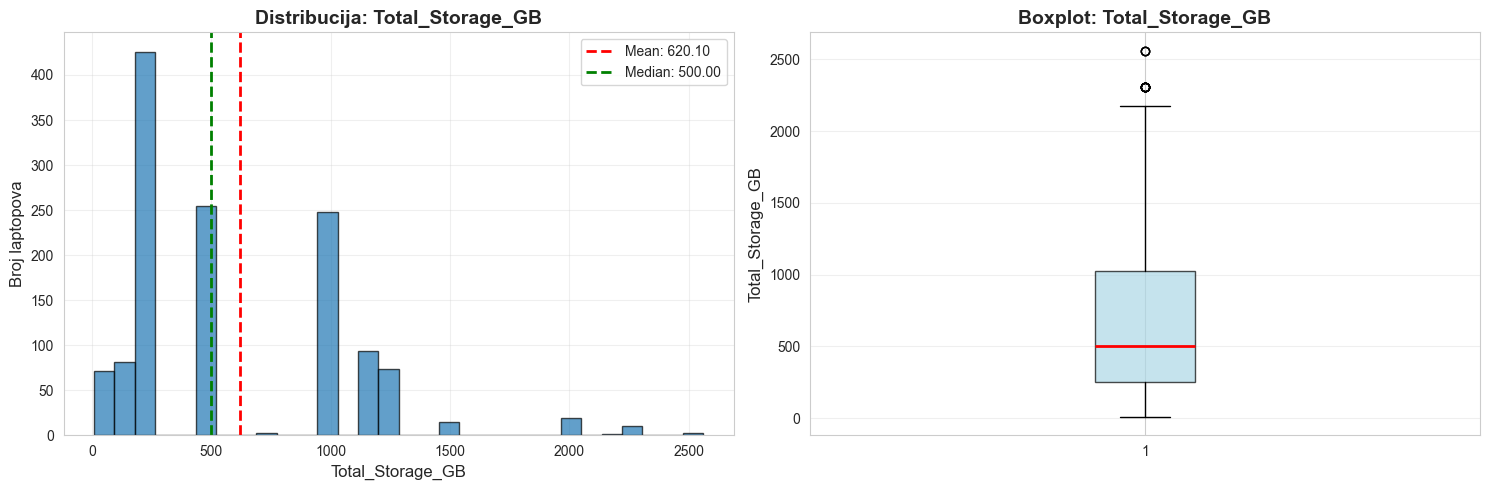

Statistika:
Srednja vrednost: 620.10
Medijana:         500.00
Std. devijacija:  479.73
Minimum:          8.00
Maximum:          2560.00
25% percentil:    256.00
75% percentil:    1024.00


In [10]:
plot_numeric_distributions(df_processed,"Total_Storage_GB")

- Prosecni kapacitet skladista iznosi 620 GB, dok je medijana 500 GB, sto ukazuje na izrazeniju desnu asimetriju distribucije.
- Polovina laptopova ima storage izmedju 256 GB i 1024 GB, sto predstavlja dominantan opseg u datasetu.
- Uoceni su znacajni outlieri u gornjem delu distribucije (preko 2000 GB), koji predstavljaju modele sa velikim kapacitetom skladista.
- vecina laptopova srednjeg kapaciteta, dok manji broj modela ima veoma veliki storage koji utice na povecanje proseka.

**Distribucija numericke promenljive Total_Pixels**

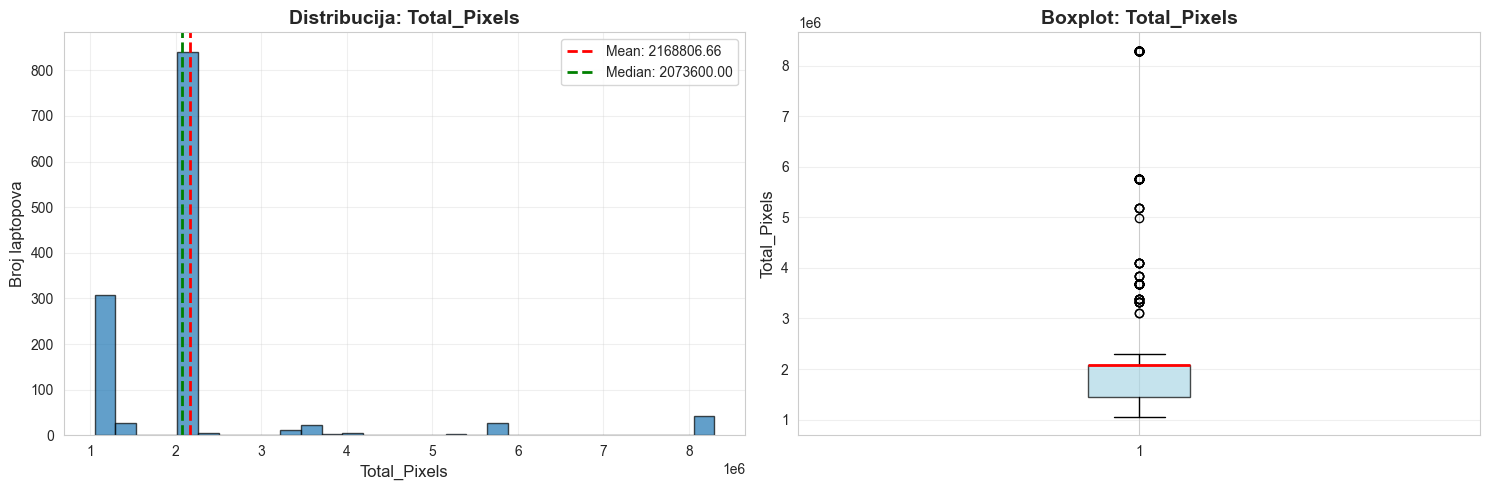

Statistika:
Srednja vrednost: 2168806.66
Medijana:         2073600.00
Std. devijacija:  1391292.40
Minimum:          1049088.00
Maximum:          8294400.00
25% percentil:    1440000.00
75% percentil:    2073600.00


In [11]:
plot_numeric_distributions(df_processed,"Total_Pixels")

- blaga desna asimetrija distribucije
- Polovina laptopova ima do 2.07 miliona piksela, sto odgovara Full HD rezoluciji i predstavlja dominantan standard u datasetu.
- znacajni outlieri u gornjem delu distribucije (preko 4 miliona piksela), koji predstavljaju modele sa visokom rezolucijom, poput 2K i 4K ekrana.
- Full HD rezolucija najzastupljenija, dok su najvise rezolucije prisutne kod manjeg broja premium modela.

Promenljive Screen_Width i Screen_Height nisu posebno analizirane, jer je njihova informacija objedinjena u promenljivoj Total_Pixels, koja predstavlja ukupnu rezoluciju ekrana.

**Distibucija numericke promenljive Has_SSD, Has_HDD, Has_Flash, Has_Hybrid**

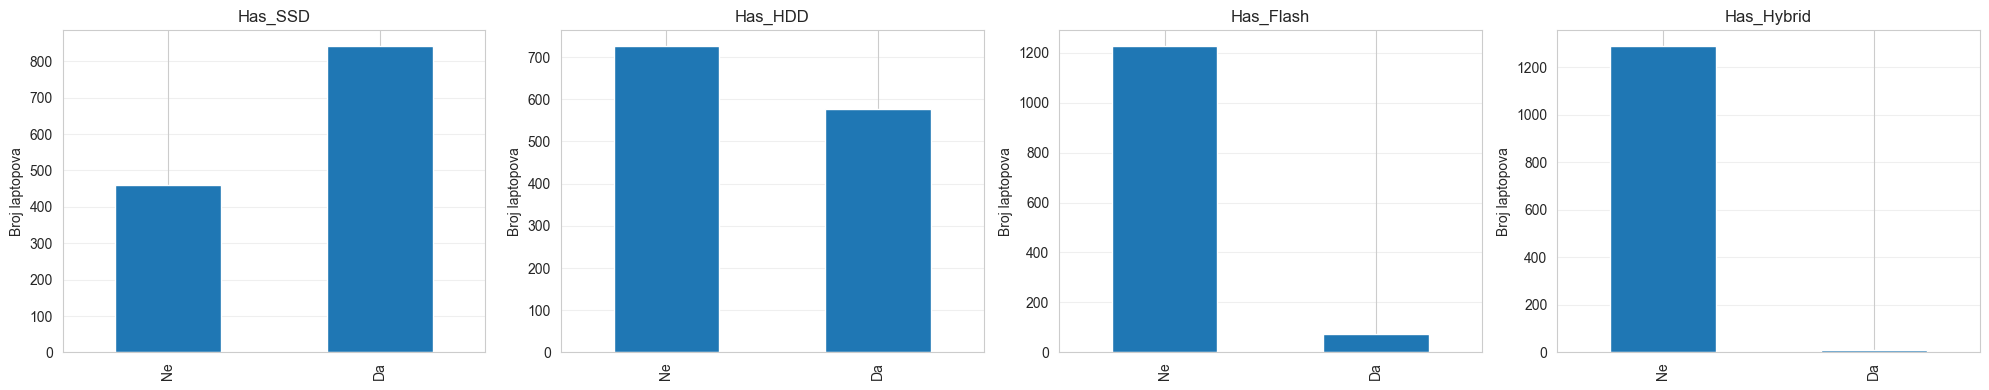

In [12]:
plot_binary_distribution(df_processed, ["Has_SSD", "Has_HDD", "Has_Flash", "Has_Hybrid"])

- SSD je prisutan kod vecine modela (oko 60%).
- HDD je zastupljen kod znacajnog dela laptopova.
- Flash i Hybrid sistemi su retko prisutni.

**Distibucija numericke promenljive TouchScreen, Retina, IPS_Panel**

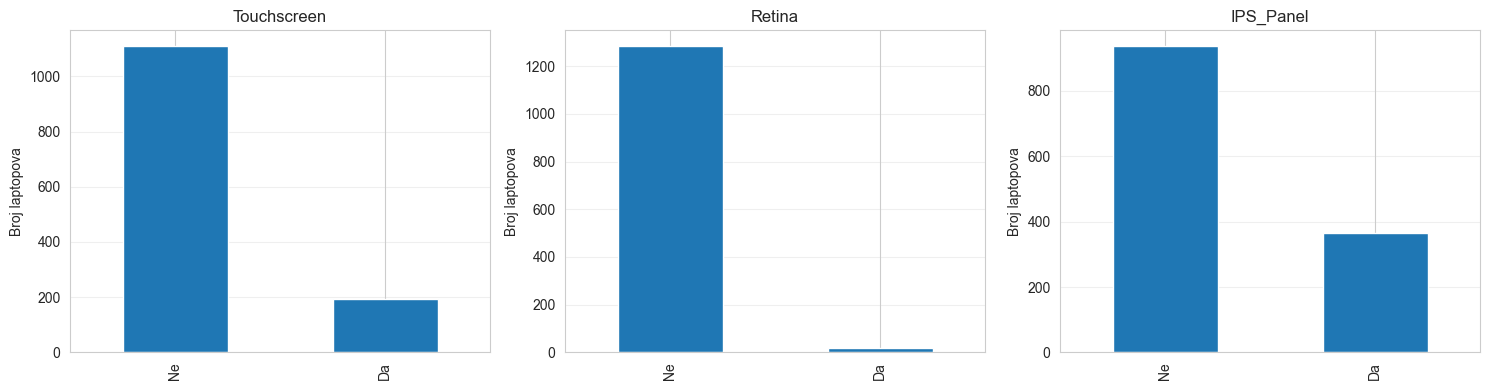

In [13]:
plot_binary_distribution(df_processed,["Touchscreen","Retina","IPS_Panel"])

- Touchscreen funkcionalnost je prisutna kod manjeg broja modela, sto ukazuje da nije standardna karakteristika u posmatranom skupu podataka.
- Retina ekrani su veoma retki i pojavljuju se kod malog broja modela, sto sugerise da su ograniceni na odredjene premium ili specijalizovane serije.
- IPS panel je zastupljen kod znacajnog dela laptopova, sto ukazuje na veci fokus proizvodjaca na kvalitet prikaza slike.
- Moze se zakljuciti da dodatne funkcionalnosti ekrana (poput Touchscreen i Retina) nisu dominantne, dok je IPS tehnologija relativno cesto prisutna u datasetu

### 3.4 Analiza cena po proizvodjacu

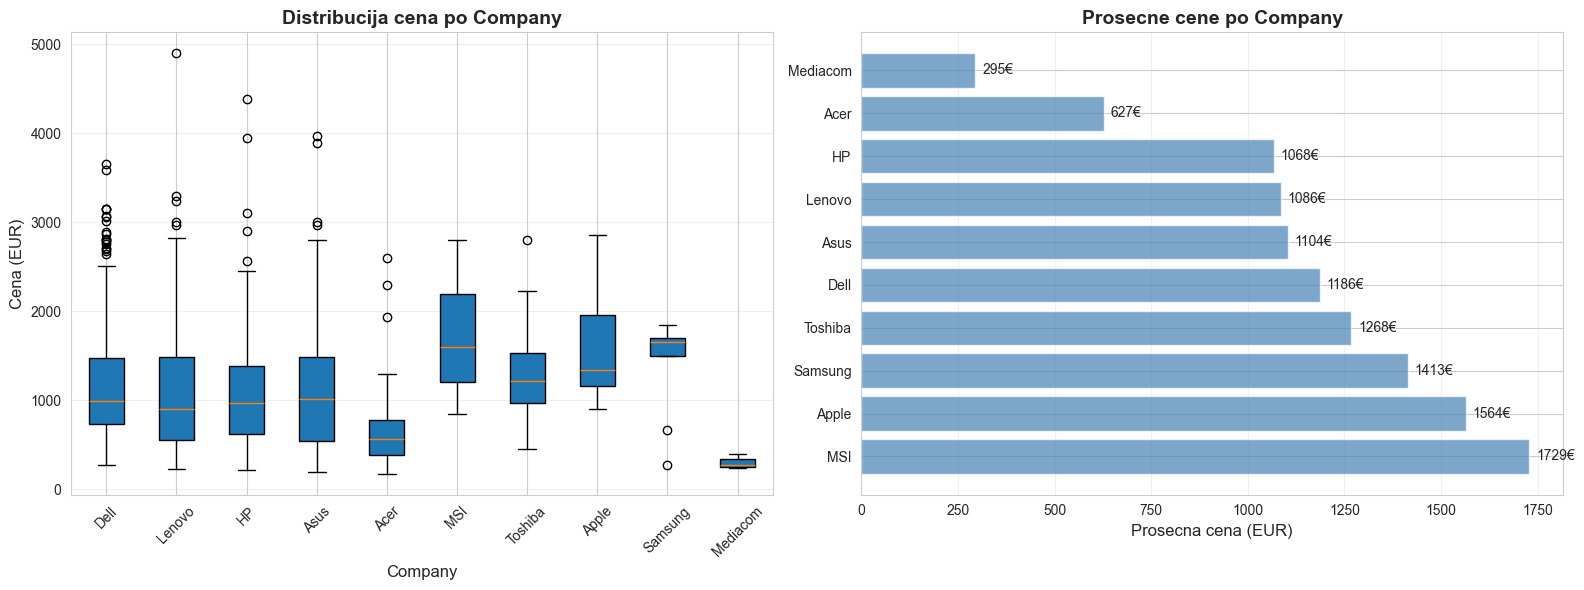

In [14]:
plot_price_by_categorical(df_processed, 'Company')

- MSI ima najvisu prosecnu cenu (~1700e)
- Apple (~1560e) i Samsung (~1410e) su takodje u visem cenovnom segmentu
- Toshiba, Dell, Asus, Lenovo i HP su uglavnom izmedju 1000e i 1300e
- Acer (~620e) i Mediacom (~300e) imaju najnize prosecne cene
- Dell, Asus i Lenovo imaju siri raspon cena, dok su Acer i Mediacom cenovno ujednaceniji

### 3.5 Analiza cena po tipu uredjaja

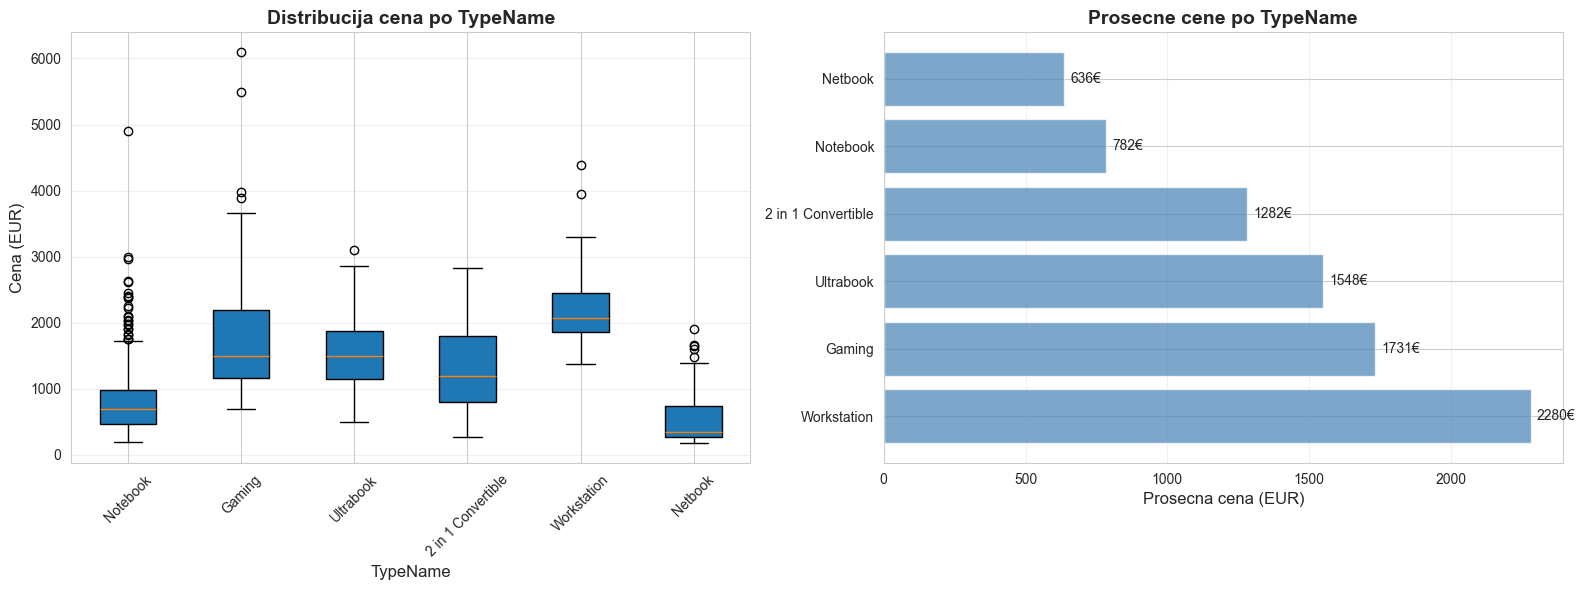

In [15]:
plot_price_by_categorical(df_processed,"TypeName")

- Workstation ima najvisu prosecnu cenu (~2280e)
- Gaming laptopovi su takodje u visem cenovnom segmentu (~1730e)
- Ultrabook modeli imaju visoku prosecnu cenu (~1540e)
- 2 in 1 Convertible su u srednjem cenovnom opsegu (~1280e)
- Notebook (~780e) i Netbook (~630e) imaju najnize prosecne cene
- Kod Gaming i Workstation modela primecuje se veca rasprsenost cena, sto ukazuje na prisustvo skupljih konfiguracija

### 3.6 Analiza cena po operativnom sistemu

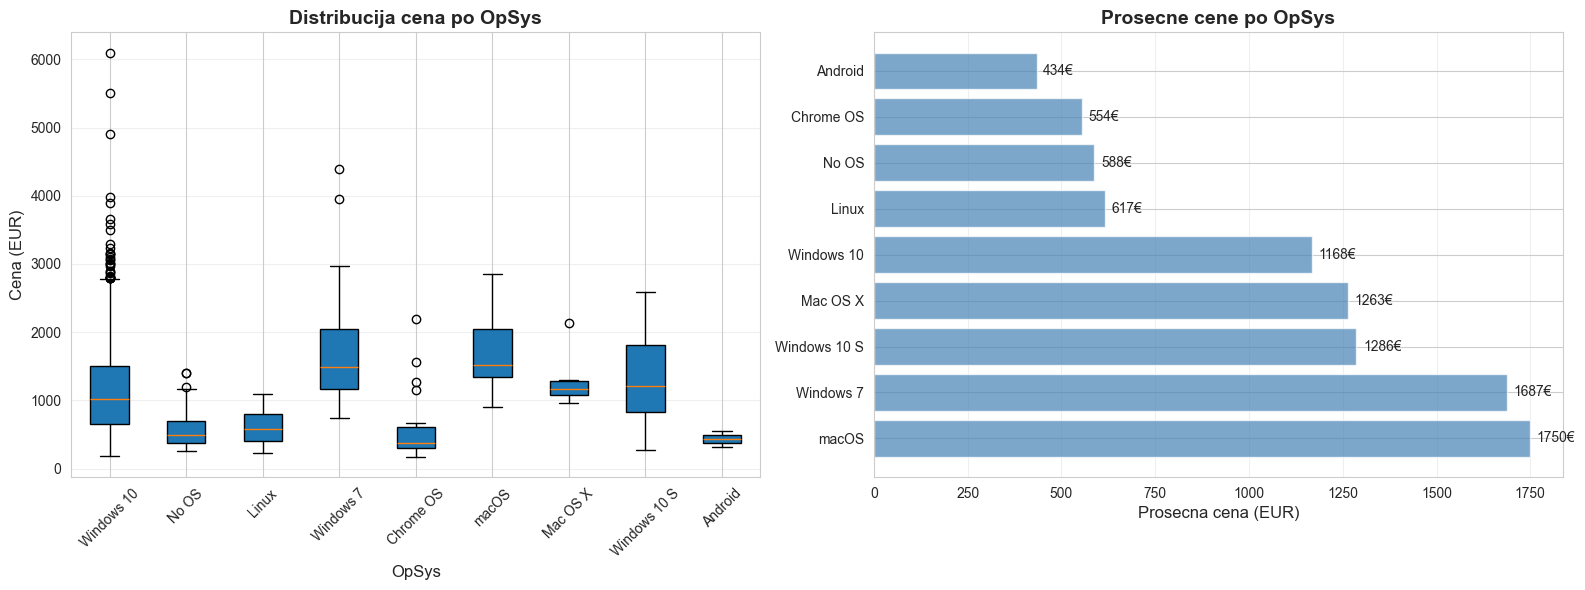

In [16]:
plot_price_by_categorical(df_processed,"OpSys")

- macOS ima najvisu prosecnu cenu (~1750e)
- Windows 7 (~1680e) i Windows 10 S (~1280e) su takodje u visem cenovnom segmentu
- Mac OS X (~1260e) i Windows 10 (~1160e) su u srednjem cenovnom opsegu
- Linux (~620e), No OS (~580e) i Chrome OS (~550e) imaju znatno nize prosecne cene
- Android ima najnizu prosecnu cenu (~430e)
- Kod Windows i macOS sistema primecuje se veca rasprsenost cena, sto ukazuje na razlicite konfiguracije

### 3.7 Analiza cene po CPU_Brand-u

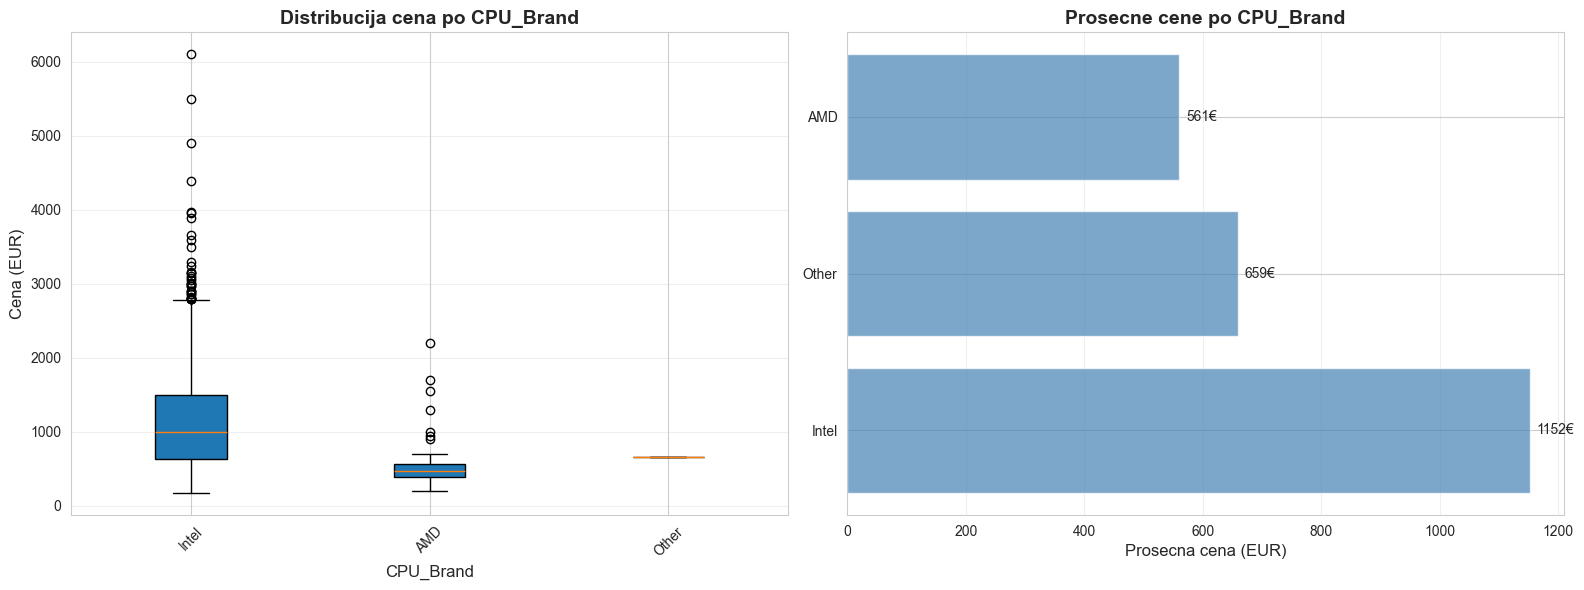

In [17]:
plot_price_by_categorical(df_processed, "CPU_Brand")

- Laptopi sa Intel procesorima imaju najvisu prosecnu cenu (~1150€).
- AMD modeli su znacajno jeftiniji (~560€).
- Iako Other ima visu prosecnu cenu, u toj grupi ima malo laptopa, pa nekoliko skupljih modela znacajno utice na prosek.
- Intel modeli pokazuju vecu rasprostranjenost cena i vise skupih konfiguracija, dok su AMD modeli cesce u srednjem cenovnom segmentu.

### 3.8 Analiza cene po CPU_Type-u

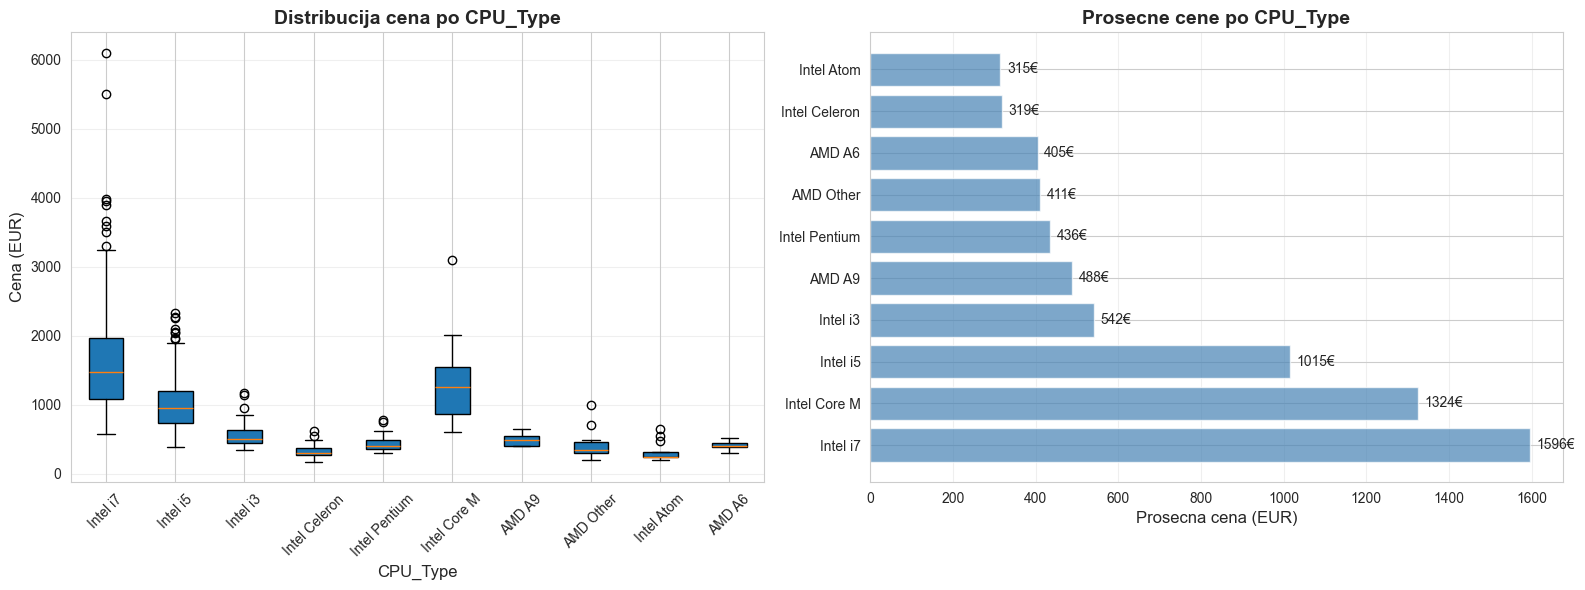

In [18]:
plot_price_by_categorical(df_processed,"CPU_Type")

- Najskuplji laptopi su oni sa Intel i7 procesorima (oko 1600€) ali ima i nekoliko extrema, zatim slede Intel Core M i Intel i5 modeli.
- Srednji cenovni rang uglavnom cine Intel i3 i AMD A9 procesori.
- Najnize cene imaju modeli sa Intel Atom, Celeron i AMD A6 procesorima (oko 300–400€).
- Jaca klasa procesora prati visu cenu laptopa.

### 3.9 Analiza cene po GPU_Brand-u 

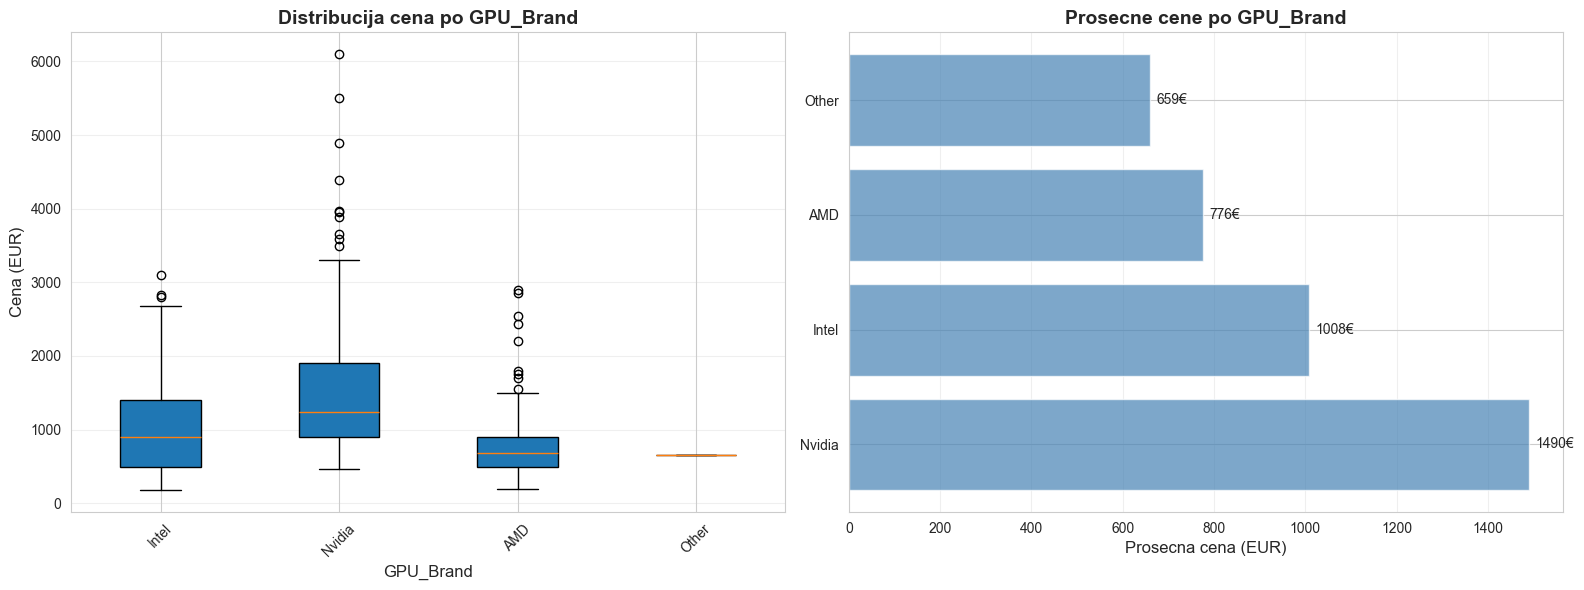

In [19]:
plot_price_by_categorical(df_processed,"GPU_Brand")

- Laptopi sa Nvidia grafickom karticom imaju najvisu prosecnu cenu (~1490€).
- Modeli sa Intel grafikom su u srednjem cenovnom rangu (~1000€).
- AMD grafika je nesto jeftinija (~770€).
- Kategorija Other ima najnizu prosecnu cenu (~650€), ali je svakako broj takvih modela mali.

### 4.0 Analiza odnosa rama i cene

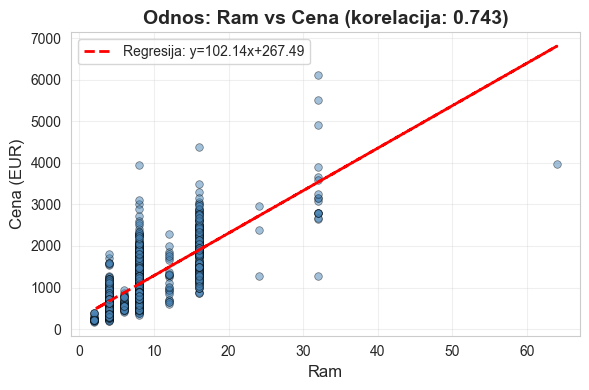

In [20]:
plot_price_by_numeric(df_processed, 'Ram')

- Izmedju RAM memorije i cene postoji jaka pozitivna veza (korelacija 0.743).
- Veca kolicina RAM-a uglavnom prati visu cenu laptopa.
- Ipak, za isti nivo RAM-a postoji raspon cena, sto ukazuje da i druge karakteristike znacajno uticu na formiranje cene.

### 4.1 Analiza odnosa tezine i cene

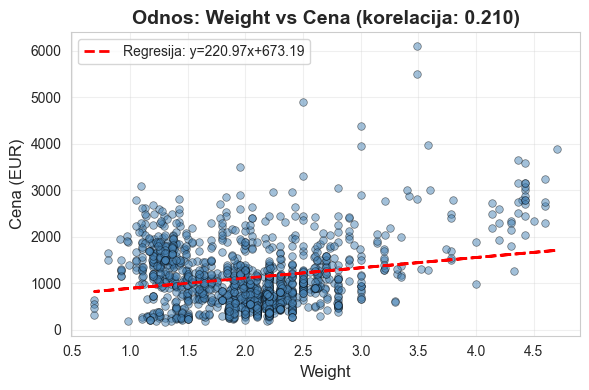

In [21]:
plot_price_by_numeric(df_processed,"Weight")

- Izmedju tezine i cene postoji slaba pozitivna korelacija (0.210).
- Tezi laptopi su u proseku blago skuplji, ali veza nije izrazena.
- Rezultati sugerisu da tezina nema izrazenu pojedinacnu povezanost sa cenom laptopa.

### 4.2 Analiza odnosa izmedju promenljive Inches i cene

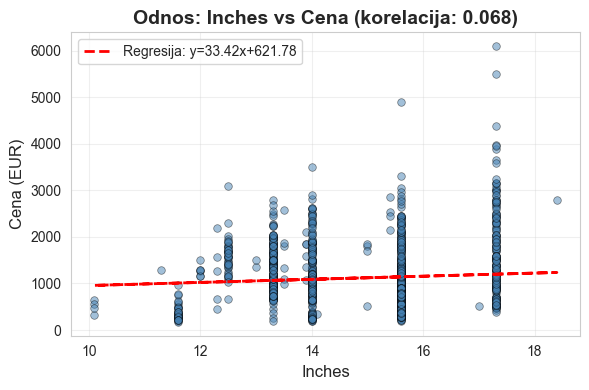

In [22]:
plot_price_by_numeric(df_processed,"Inches")

- Izmedju velicine ekrana (Inches) i cene postoji veoma slaba pozitivna korelacija (0.068).
- Veca dijagonala ekrana ne prati znacajno visu cenu.
- To sugerise da velicina ekrana nema izrazenu pojedinacnu povezanost sa cenom laptopa.

### 4.3 Analiza odnosa Total_Pixels i cene

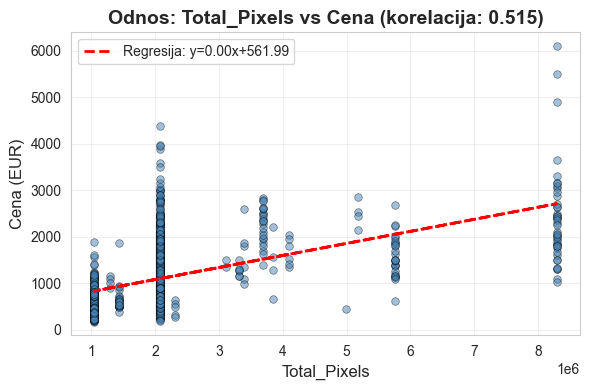

In [23]:
plot_price_by_numeric(df_processed,"Total_Pixels")

- Izmedju ukupnog broja piksela i cene postoji umerena pozitivna povezanost (0.515), sto pokazuje mogucnost da su modeli sa vecom rezolucijom u proseku skuplji. 

### 4.4 Analaiza odnosa  Total_Storage_GB i cene

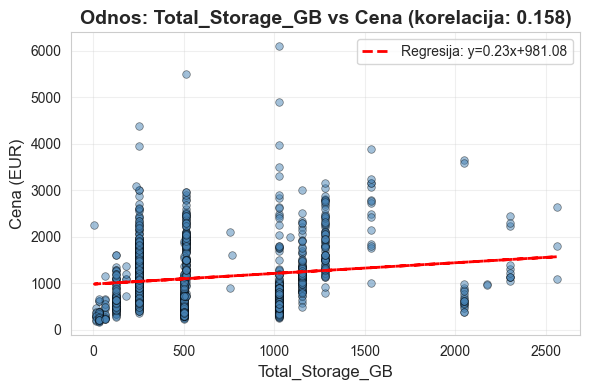

In [24]:
plot_price_by_numeric(df_processed,"Total_Storage_GB")

- Izmedju ukupnog kapaciteta skladista (Total_Storage_GB) i cene postoji slaba pozitivna korelacija (0.158).
- Veci kapacitet memorije blago prati visu cenu, ali veza nije izrazena.
- Rezultati sugerisu da ukupna memorija sama po sebi nema jaku pojedinacnu povezanost sa cenom laptopa

### 4.5 Analiza odnosa CPU_Speed_GHz i cene

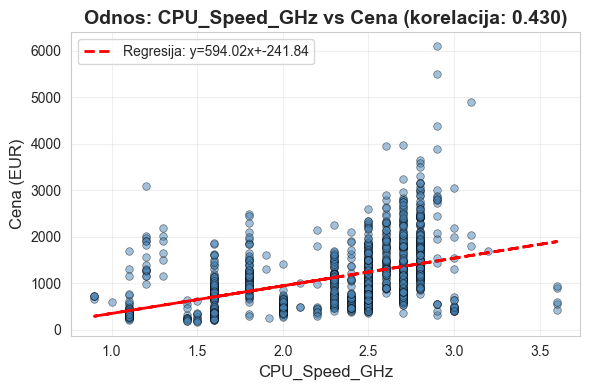

In [25]:
plot_price_by_numeric(df_processed,"CPU_Speed_GHz")

- Izmedju brzine procesora (CPU_Speed_GHz) i cene postoji umerena pozitivna korelacija (0.430).
- Laptopi sa brzim procesorima u proseku imaju visu cenu.
- Rezultati ukazuju da brzina procesora ima znacajniju povezanost sa cenom u odnosu na tezinu ili velicinu ekrana.

### 4.6 Distribucija i odnos tipa memorije sa cenom

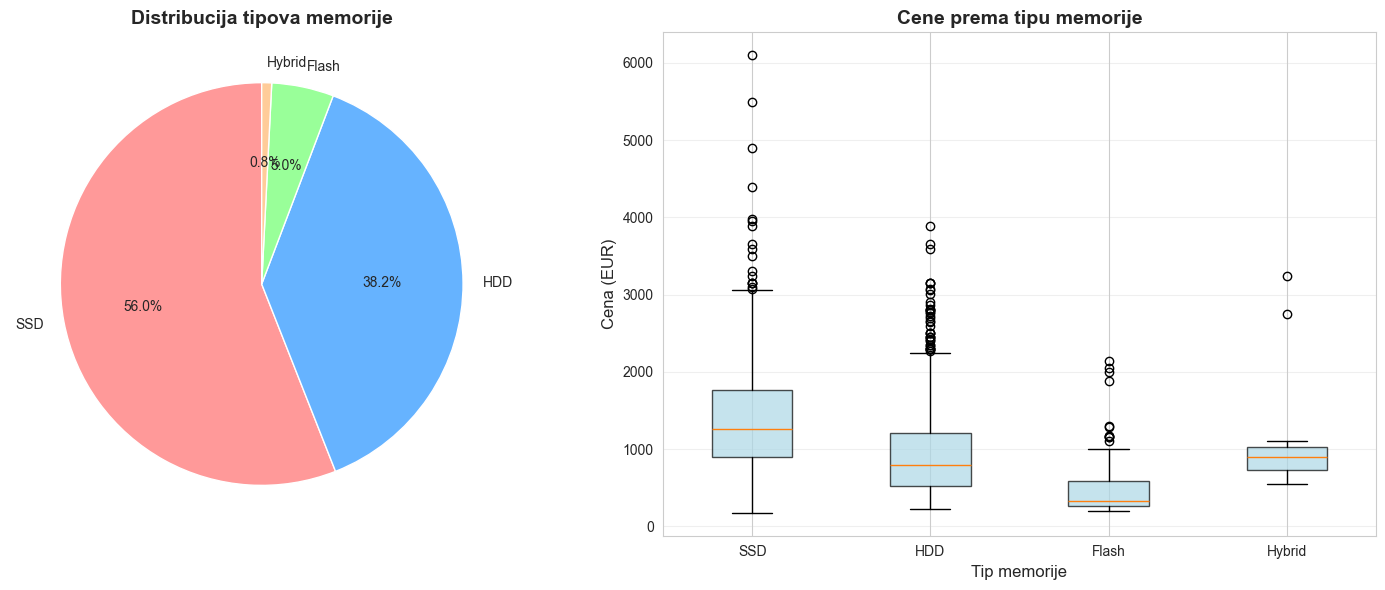

In [26]:
plot_memory_types_distribution(df_processed)

- SSD je najzastupljeniji tip memorije i povezan je sa višim cenama.
- HDD modeli su u proseku jeftiniji, dok je Flash prisutan kod najnižih cenovnih kategorija.
- Rezultati ukazuju da tip memorije ima značajnu povezanost sa cenom laptopa.

### 4.7 Analiza odnosa has_multidrvie i cene

In [28]:
analyze_multidrive_effect(df_processed)

Prosecne cene:
Bez MultiDrive: 1029.39 EUR
Sa MultiDrive:  1620.09 EUR
Razlika u prosecnoj ceni: 590.70 EUR

T-statistika: 11.646
P-vrednost: 0.00000


- Laptopi sa vise diskova imaju statisticki znacajno visu prosecnu cenu u odnosu na ostale modele.
- Rezultati sugerisu da MultiDrive konfiguracija moze biti povezana sa naprednijim i skupljim segmentom trzista.

### 4.8 Detekcija outliera (IQR metoda)

In [29]:
outliers = detect_outliers_iqr(df_processed, 'Price_euros')
print(f"\nPrimer outliera:")
print(outliers[['Company', 'TypeName', 'Ram', 'CPU_Brand', 'GPU_Brand', 'Price_euros']].head(5))


Outlier analiza:
Q1 (25%):         599.00
Q3 (75%):         1487.88
IQR:              888.88
Donja granica:    -734.32
Gornja granica:   2821.20
Broj outliera:    29 (2.23%)


Primer outliera:
    Company            TypeName  Ram CPU_Brand GPU_Brand  Price_euros
17    Apple           Ultrabook   16     Intel       AMD       2858.0
190  Lenovo  2 in 1 Convertible   16     Intel     Intel       2824.0
196   Razer              Gaming   32     Intel    Nvidia       6099.0
204    Dell         Workstation   16     Intel    Nvidia       3055.0
238    Asus              Gaming   32     Intel    Nvidia       3890.0


- Outlieri su identifikovani primenom IQR metode (Q1 − 1.5×IQR, Q3 + 1.5×IQR). Posebno je analizirana ciljna promenljiva  Price_euros, kao i kljucni numericki atributi (RAM, CPU_Speed_GHz, Total_Storage_GB, Weight).
- Ekstremne vrednosti nisu automatski uklonjene, jer mogu predstavljati realne premium ili budzet modele. Umesto uklanjanja, analizirana je stabilnost modela u njihovom prisustvu poredjenjem OLS i robusne Huber regresije

### 4.9 Matrica korelacija - identifikacija multikolinearnosti

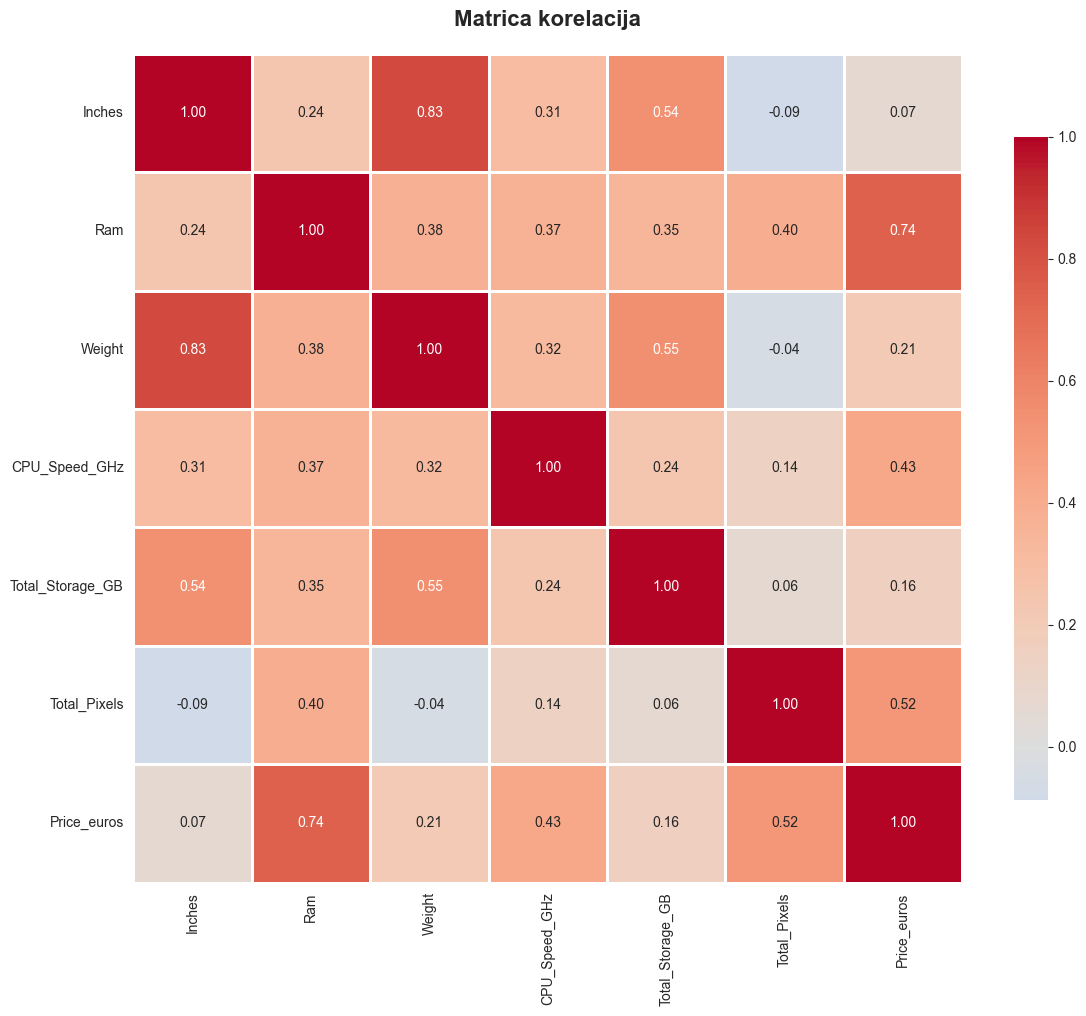

Ram                      :  0.743
Total_Pixels             :  0.515
CPU_Speed_GHz            :  0.430
Weight                   :  0.210
Total_Storage_GB         :  0.158
Inches                   :  0.068



In [30]:
numeric_cols = ['Inches', 'Ram','Weight', 'CPU_Speed_GHz', 'Total_Storage_GB', 'Total_Pixels']
plot_correlation_matrix(df_processed, numeric_cols)

- Na osnovu korelacione matrice, Ram ima najjacu pozitivnu povezanost sa cenom (r = 0.74), sto ukazuje da kolicina RAM memorije znacajno utice na cenu laptopa.
- Total_Pixels (r = 0.52) i CPU_Speed_GHz (r = 0.43) pokazuju umerenu pozitivnu povezanost sa cenom, dok su Weight, Total_Storage_GB i Inches slabo povezani sa cenom.
- Izmedju kontinuiranih prediktora nije uocena jaka medjusobna korelacija (r < 0.7), sto ukazuje da ne postoji ozbiljna multikolinearnost.

###  VIF analiza - kvantifikacija multikolinearnosti

In [31]:
vif_results = calculate_vif(df_processed, numeric_cols)

VIF rezultati:
            Feature        VIF
0            Inches  44.162142
3     CPU_Speed_GHz  26.276525
2            Weight  24.359382
1               Ram   6.030241
5      Total_Pixels   4.243438
4  Total_Storage_GB   3.897939


- Neke features imaju VIF > 10, sto ukazuje na multikolinearnost
- Ridge ce pomoci u stabilizaciji koeficijenata

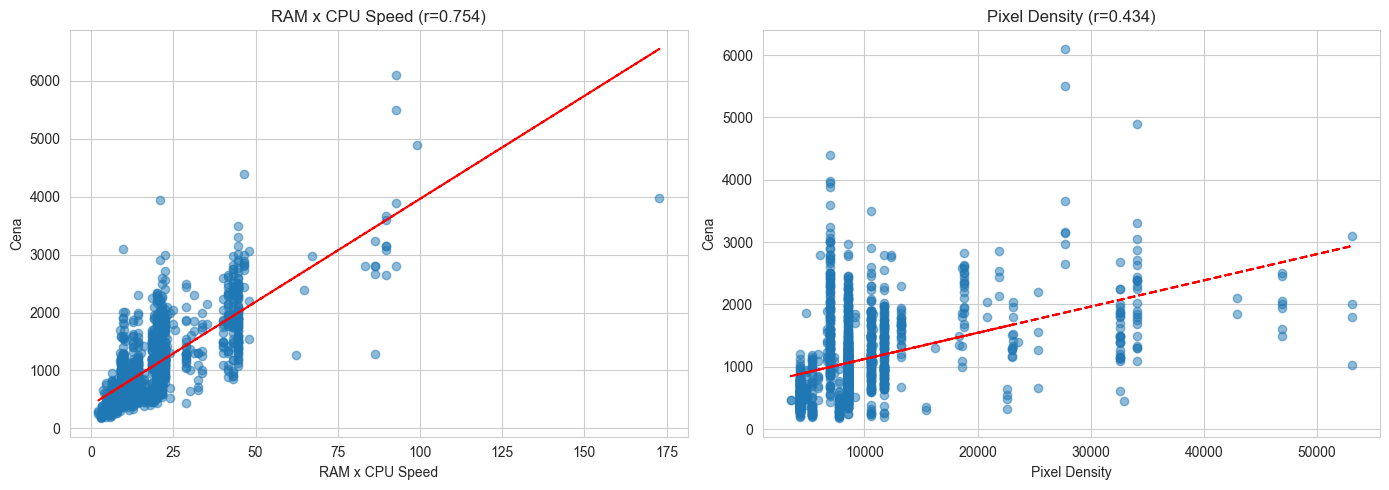

In [32]:
plot_key_interactions(df_processed)

- Uocena je izrazena pozitivna povezanost izmedju kombinacije RAM memorije i brzine procesora i cene laptopa (r ~ 0.75).
- Grafikon pokazuje jasan rast cene sa povecanjem kombinovane vrednosti RAM-a i CPU brzine.
- Gustina piksela pokazuje umerenu pozitivnu korelaciju sa cenom (r ~ 0.43).
- Veza izmedju kvaliteta ekrana i cene je prisutna, ali slabije izrazena u odnosu na kombinaciju RAM-a i procesora.
- Rezultati sugerisu da performanse uredjaja imaju jacu linearnu povezanost sa cenom u odnosu na karakteristike prikaza.

<a id='modeli'></a>
## 5. Treniranje regresionih modela
1. OLS - baseline model
2. Ridge - za borbu protiv multikolinearnosti
3. Huber - za robusnost prema outlierima

In [33]:
analysis = RegressionModels()

cols_to_drop = ['Screen_Width', 'Screen_Height','Has_MultiDrive', 'Has_Flash']
X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

**Analaiza multikolinearnosti pomocu VIF mere** 

- VIF = 1 → nema korelacije
- 1 – 5 → umerena korelacija
- 5 – 10 → visoka korelacija
- 10 → kriticna multikolinearnost

In [34]:
analysis.analyze_multicollinearity(X_train)

Inches: 3.83
Ram: 2.21
Weight: 3.96
Total_Pixels: 1.52
IPS_Panel: 1.18
Touchscreen: 1.48
Retina: 1.12
Has_SSD: 2.51
Has_HDD: 6.48
Has_Hybrid: 1.31
Total_Storage_GB: 4.52
CPU_Speed_GHz: 1.32


### 5.0 Treniranje modela

In [35]:
analysis.train_all_models(X_train, y_train, X_val, y_val)

OLS
  Train → MAE: 224.59, R2: 0.7931
  Val   → MAE: 243.19, R2: 0.7938

Ridge
  Train → MAE: 226.43, R2: 0.7912
  Val   → MAE: 244.93, R2: 0.7858

Huber
  Train → MAE: 216.72, R2: 0.7821
  Val   → MAE: 246.03, R2: 0.7729



### 5.1 Evaluacija na test skupu

In [36]:
analysis.evaluate_on_test(X_test, y_test)

OLS
  MAE: 232.09
  R2 : 0.7590

Ridge
  MAE: 229.42
  R2 : 0.7624

Huber
  MAE: 214.99
  R2 : 0.7775



### 5.2 Analiza predikcija i reziduala

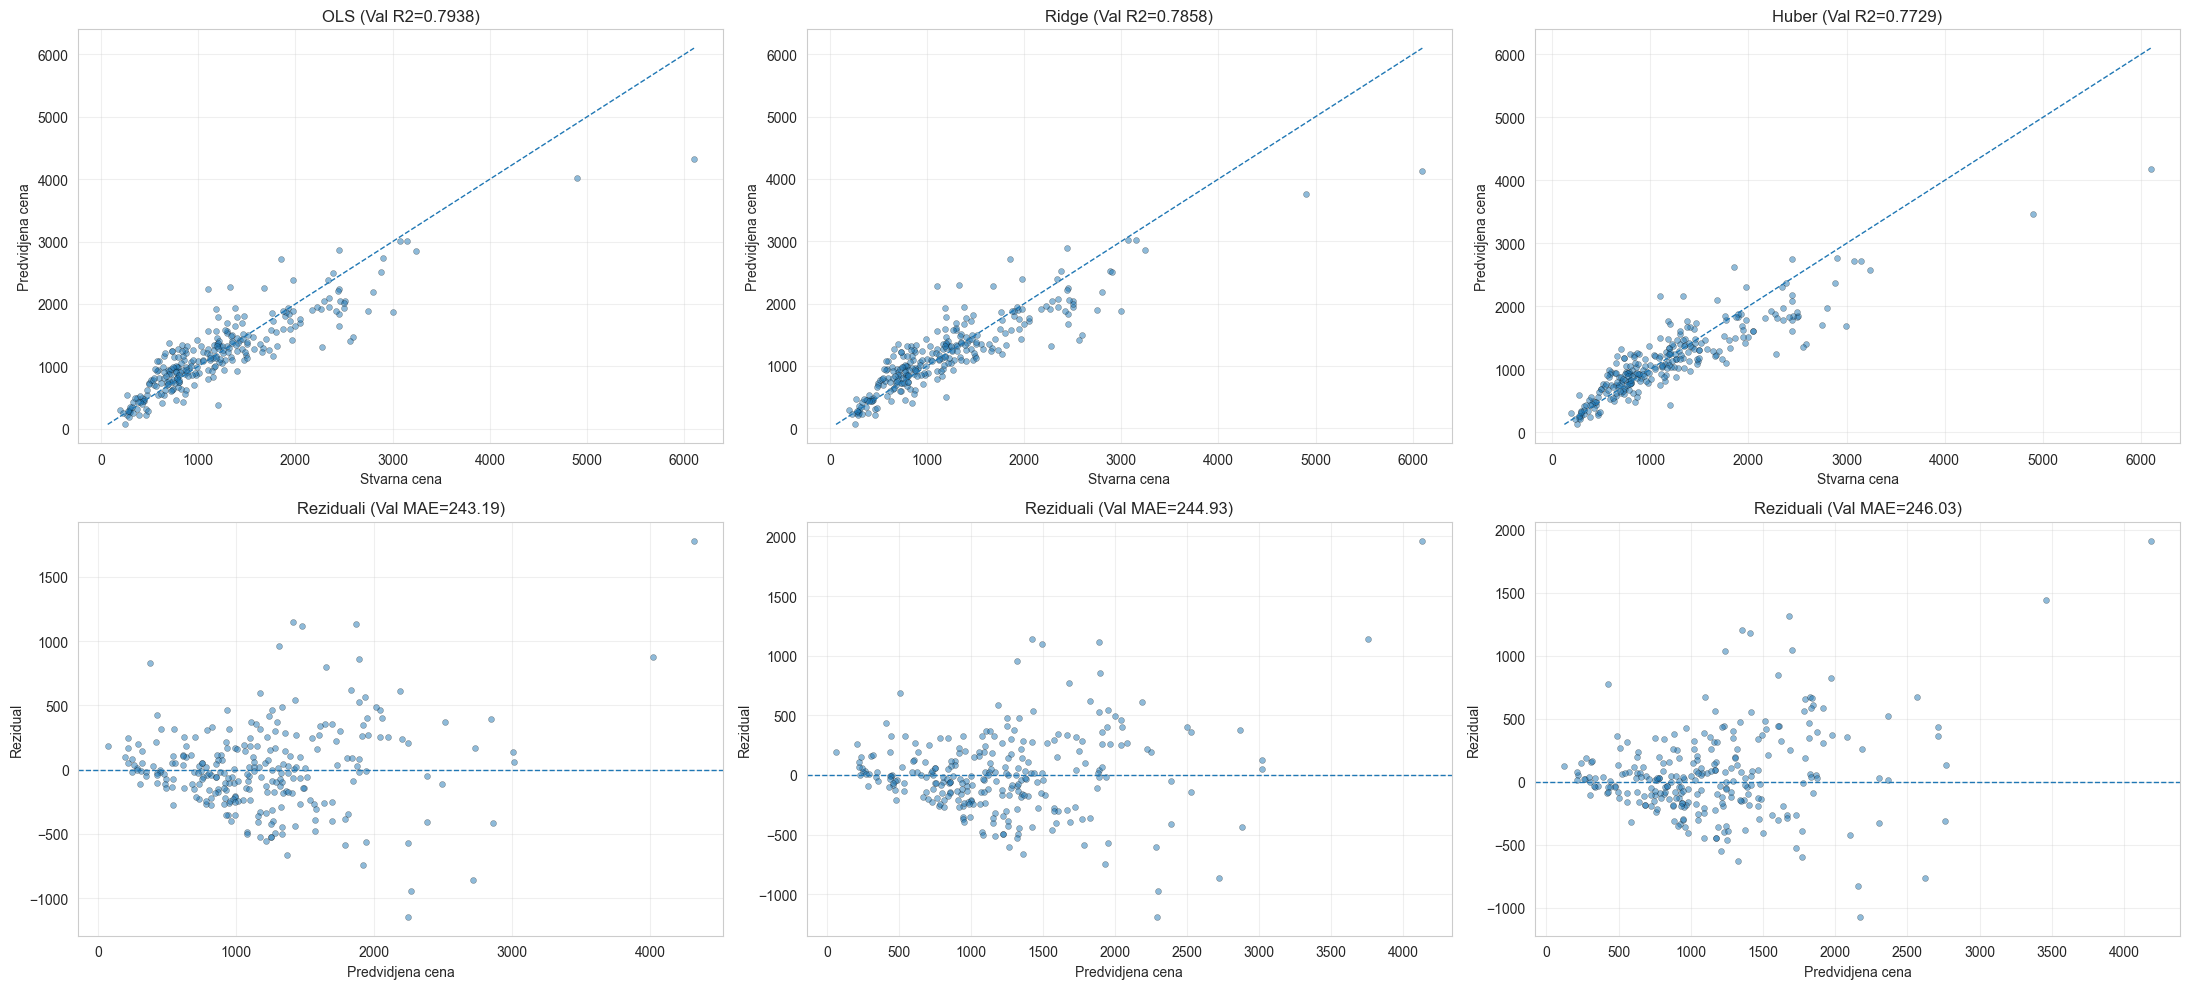

In [37]:
analysis.plot_predictions_and_residuals()

- Svi modeli pokazuju dobro slaganje sa dijagonalnom linijom, sto ukazuje na solidnu preciznost predikcije.
- Reziduali su uglavnom centrirani oko nule bez jasnog sistematskog obrasca.
- Ne primecuju se drasticna odstupanja niti izrazeni problemi heteroskedasticnosti.
- Modeli su stabilni, uz blagu prednost Huber modela.

### 5.3 Poredjenje metrika izmedju modela

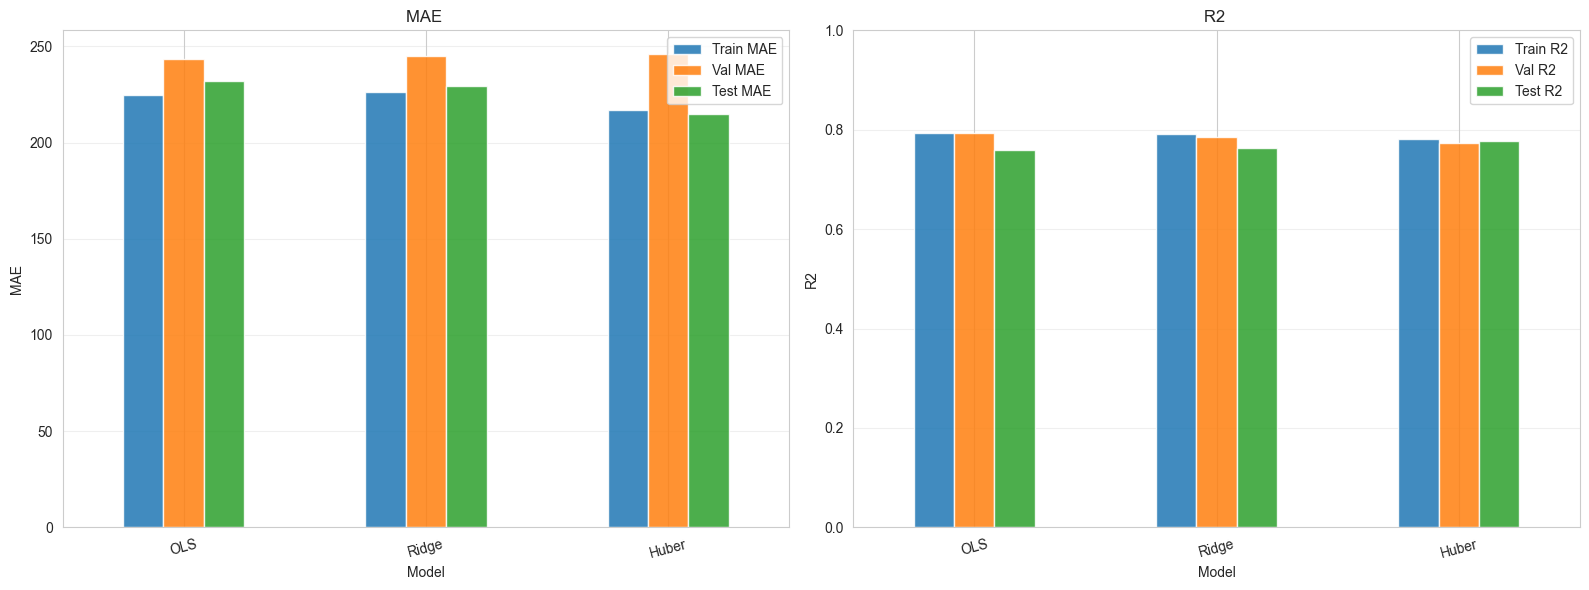

In [38]:
analysis.plot_model_comparison()

- Svi modeli imaju slicne performanse
- R² vrednosti su visoke (~0.80) 
- MAE 200€ - modeli grese u proseku za oko 10-15% cene

### 5.4 Stabilnost koeficijenta  OLS - Ridge

In [39]:
analysis.compare_ols_ridge_coefficients(X_train.columns)

Feature                               OLS      Ridge      Razlika
---------------------------------------------------------------------------
Company_LG                        613.641    275.629      338.012
Company_Razer                    1146.159    850.769      295.390
CPU_Type_Intel Xeon               810.038    545.050      264.988
CPU_Type_AMD Ryzen                448.186    222.694      225.492
Company_Google                    420.723    230.765      189.958
OpSys_Windows 7                   602.988    427.707      175.281
OpSys_Linux                        78.059    -92.572      170.632
OpSys_Windows 10                  183.458     15.654      167.804
OpSys_Chrome OS                   116.179    -42.372      158.551
OpSys_No OS                       -40.044   -198.063      158.019
Company_Apple                     226.229     86.362      139.867
OpSys_Windows 10 S                188.161     53.699      134.462
Company_Microsoft                 208.590     78.969      129.620


Ridge model daje stabilnije i umerenije koeficijente u odnosu na OLS, sto ukazuje na prisustvo multikolinearnosti. Regularizacija smanjuje preuvelicane procene i doprinosi pouzdanijoj interpretaciji uticaja atributa na cenu.

### 5.5 Feauture importance za model

In [40]:
analysis.analyze_feature_importance(X_train.columns, model_name="Ridge")


Ridge
-----------------------------------------------------------------
Feature                                 Koeficijent
-----------------------------------------------------------------
Company_Razer                               850.769
CPU_Type_Intel Xeon                         545.050
TypeName_Workstation                        480.228
OpSys_Windows 7                             427.707
Ram                                         288.802
Company_LG                                  275.629
Company_Google                              230.765
CPU_Type_AMD Ryzen                          222.694
TypeName_Notebook                          -205.419
OpSys_No OS                                -198.063
CPU_Type_AMD A12                           -184.123
CPU_Brand_Intel                             181.976
Company_Samsung                             179.900
Company_MSI                                 175.676
CPU_Type_Intel Atom                        -175.334
Company_Toshiba              

Rezultati Ridge modela pokazuju da najveci pozitivan uticaj na cenu imaju premium brendovi, poput Razer, kao i procesori visoke klase kao sto su Intel Xeon i AMD Ryzen. RAM memorija takodje ima znacajan pozitivan efekat na cenu. Sa druge strane, slabiji procesori poput Intel Atom i Intel i3 imaju negativan uticaj, sto ukazuje na nizi cenovni segment.

### 5.6 Poredjenje vaznosti feauturesa


MODEL: OLS
Company_Razer                       +1146.16
CPU_Type_Intel Xeon                 +810.04
Company_LG                          +613.64
OpSys_Windows 7                     +602.99
TypeName_Workstation                +455.94
CPU_Type_AMD Ryzen                  +448.19
Company_Google                      +420.72
Company_Samsung                     +289.08
CPU_Brand_Intel                     +283.72
Ram                                 +283.26
Company_MSI                         +248.03
Company_Xiaomi                      -231.98
Company_Apple                       +226.23
Company_Toshiba                     +221.77
TypeName_Notebook                   -217.99

MODEL: Ridge
Company_Razer                       +850.77
CPU_Type_Intel Xeon                 +545.05
TypeName_Workstation                +480.23
OpSys_Windows 7                     +427.71
Ram                                 +288.80
Company_LG                          +275.63
Company_Google                      +230.77
CPU_T

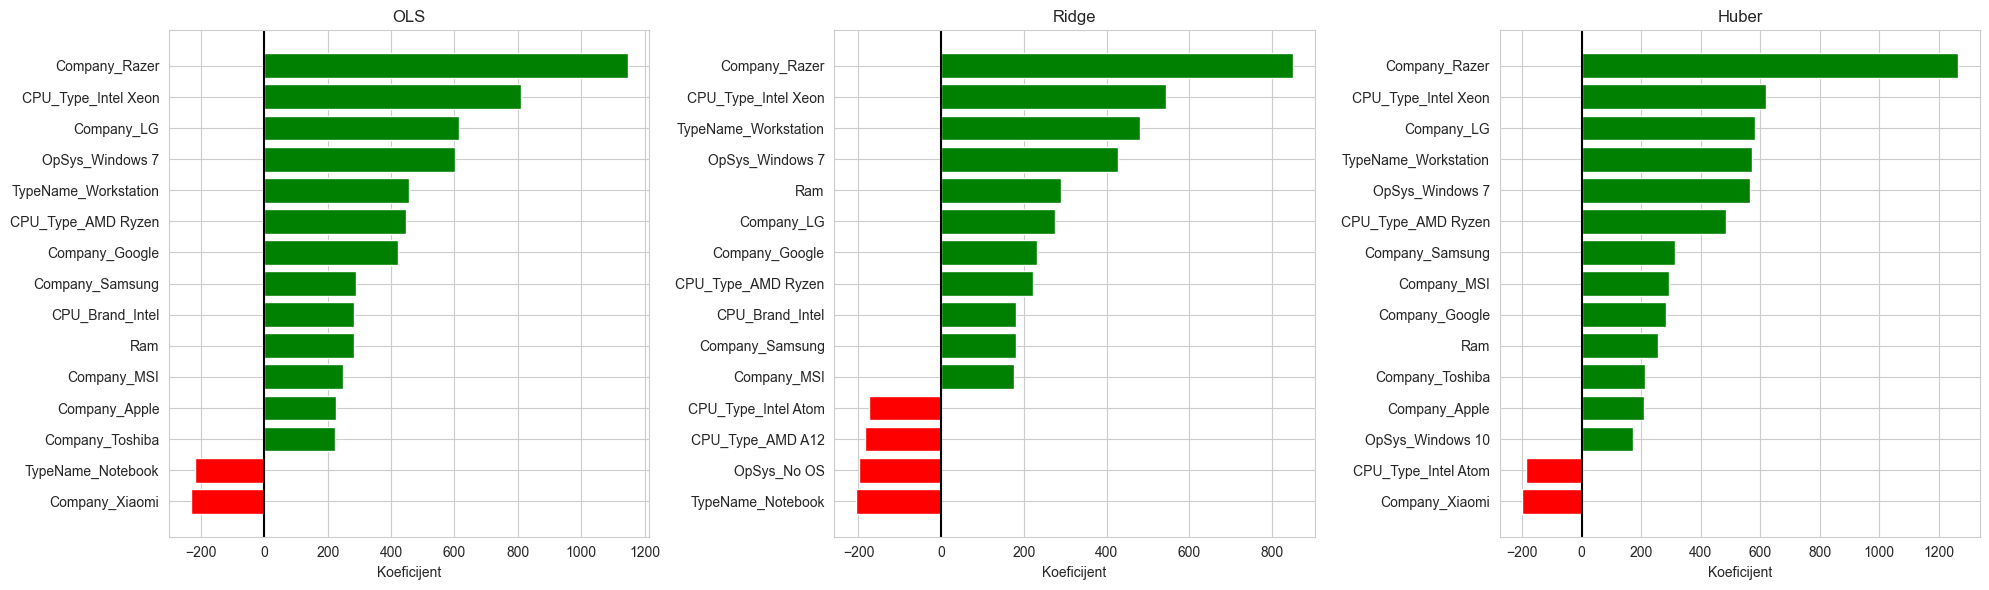

In [41]:
analysis.plot_feature_importance_comparison(X_train.columns, top_n=15)

### 5.7 Outliere impact

In [42]:
analysis.analyze_outlier_impact(X_train, y_train, X_val, y_val, outlier_threshold_pct=95)

OLS:
  MAE with=243.19  without=277.96  diff=-34.78
  R2  with=0.7938  without=0.5899  diff=-0.2039
Ridge:
  MAE with=244.93  without=272.80  diff=-27.87
  R2  with=0.7858  without=0.6276  diff=-0.1582
Huber:
  MAE with=246.03  without=282.24  diff=-36.21
  R2  with=0.7729  without=0.5601  diff=-0.2128



Uklanjanje najvisih pet procenata cena dovodi do pogorsanja performansi svih modela, sto pokazuje da ekstremne vrednosti nisu greske u podacima. One predstavljaju realan premium segment trzista i imaju znacajnu ulogu u objasnjavanju varijacije cena

### Uticaj branda na cenu 

In [43]:
brand_df = analysis.brand_effect_report(X_train.columns, top_n=3)


Brendovi koji povecavau cenu (pozitivan koeficijent):
  Company_Razer              coef = +850.769
  Company_LG                 coef = +275.629
  Company_Google             coef = +230.765

Bbrendovi koji Ssmanjuju cenu (negativan koeficijent):
  Company_Xiaomi             coef = -134.904
  Company_Chuwi              coef = -92.897
  Company_Fujitsu            coef = -91.711


<a id='uvod'></a>
## Zakljucak


### Tehnicki atributi koji imaju najveci uticaj

Najveci pozitivan uticaj imaju:
- RAM (jako znacajan i stabilan pozitivan koeficijent)
- CPU visoke klase (npr. i7, i9, Ryzen)
- GPU Nvidia (posebno kod gaming segmenta)
- SSD prisustvo
- Veca rezolucija / total pixels

Negativan ili slabiji uticaj imaju:

- HDD bez SSD-a
- Nizi CPU modeli (npr. i3, Celeron)
- Odredjeni budzet brendovi

Cena laptopa primarno zavisi od performansi (RAM + CPU + GPU), dok su ostale karakteristike sekundarne.

### Koliko Ram i tip procesora doprinose ceni?

RAM:
Ima stabilan i znacajan pozitivan koeficijent.
Povecanje RAM memorije direktno povecava cenu.

CPU:
Tip procesora pravi jasnu razliku:
- i7/i9 i Ryzen imaju jak pozitivan efekat
-i3 i slabiji modeli imaju znatno manji efekat

### Da li brend znacajno utice nakon kontrole tehnickih specifikacija?

Rezultati Ridge regresije pokazuju da brend ima znacajan i nezavisan uticaj na cenu laptopa. Pojedini premium brendovi, poput Razer i LG , zadrzavaju visok pozitivan koeficijent, sto ukazuje da su u proseku znatno skuplji u odnosu na bazni brend, cak i kada su tehnicke specifikacije iste. Sa druge strane, brendovi poput Xiaomi imaju negativan koeficijent, sto znaci da su jeftiniji uz slicne performanse. Ovi rezultati potvrduju da reputacija i trzisno pozicioniranje proizvodjaca igraju vaznu ulogu u formiranju cene.

### Kako extremne vrednosti uticu na stavilnost modela?

- Ekstremne vrednosti nisu greske, vec realan premium segment trzista.
- Njihovo uklanjanje pogorsava model.
- Standardna regresija ostaje adekvatna.

### Da li Ridge daje stabilnije procene?

Ridge je metodoloski najstabilniji model za interpretaciju modela
- smanjuje extremne koeficijente
- daje stabilnije procene
- manje je osetljiv na korelaciju izmedju feature-a

### Koliko je izrazen problem multikolinearnosti?

- Na osnovu korelacione matrice i VIF analize, postoji umerena multikolinearnost (storage varijable, CPU dummy varijable).
- Poredjenje OLS i Ridge pokazuje razlike u koeficijentima.
- Multikolinearnost postoji i utice na nestabilnost OLS koeficijenata.




Sprovedena analiza pokazala je da kombinacija tehnickih performansi, brenda i memorijskih karakteristika u velikoj meri doprinosi objasnjenju varijabilnosti cena laptopa. Primena regularizovanih metoda potvrdila je stabilnost procena u prisustvu multikolinearnosti i ekstremnih vrednosti. Rezultati rada pruzaju jasnu interpretaciju faktora koji najvise doprinose formiranju cene na trzistu laptopa.